# The Interplay of Occupational Stress, Lifestyle Factors, and Sleep Quality
### A Public Health Perspective on Sleep Disorders
**Author:** Nahom Mesfin
**Institution:** George Washington University, Milken Institute School of Public Health
**Course:** PUBH 1142: Introduction to Health Data Science
**Date:** [Insert Date]

In [36]:
# Import all required packages for the analysis
import numpy as np
import sys
!{sys.executable} -m pip install pandas
import pandas as pd
from scipy import stats
!{sys.executable} -m pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Set high-resolution displays for standard professional output
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid", palette="muted")


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Additional required imports
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

print("✓ All statistical library imports successful")

✓ All imports successful


NameError: name 'sns' is not defined

## INTRODUCTION
Sleep is a fundamental pillar of biological health [12], yet sleep disorders and poor sleep hygiene have become a growing public health crisis in modern society [3]. In the context of global health data science, understanding the drivers of sleep quality is essential, as sleep deprivation is linked to chronic conditions such as cardiovascular disease [6], metabolic consequences like obesity [7], and impaired cognitive performance [1, 13]. This research focuses on how various lifestyle factors—including physical activity, daily steps, and occupational categories—influence sleep duration and the prevalence of disorders like insomnia and sleep apnea [2].

Current research has established strong correlations between high-stress environments, heavy workloads, and sleep fragmentation [10, 11]. However, there remains a knowledge gap regarding how physiological categories (like BMI) interact with these occupational stress issues in working populations. While many studies focus on clinical populations, there is a need for data-driven analysis of general populations to identify early warning signs of sleep deterioration and mitigate long-term healthcare costs [5].

The primary objective of this research is to analyze the chosen dataset to identify the strongest predictors of sleep quality. Specifically, this study aims to determine if there is a significant difference in sleep duration between those with and without sleep disorders, and if BMI categories are heavily associated with the presence of these disorders.

## BACKGROUND
The relationship between lifestyle and sleep is multifaceted, involving biological, environmental, and behavioral components. A significant body of literature suggests that physical activity acts as a non-pharmacological intervention for improving sleep duration and aligning with recommended sleep timelines [2]. According to general public health guidelines, regular physical activity is associated with reduced sleep latency and increased deep sleep stages. This dataset allows for a granular look at these variables by including "Daily Steps" as a quantitative measure of activity alongside subjective "Sleep Quality" ratings.

Occupational health research has increasingly identified "Burnout" and "Work-Related Stress" as significant disruptors of the circadian rhythm [10]. Studies in the field of public health indicate that shift workers and those in high-stress environments face a much higher risk of incident sleep disturbances [11]. This analysis provides a unique opportunity to compare these categories, as the data contains specific labels for high-stress professions such as Doctors, Nurses, and Engineers.

Furthermore, the integration of Body Mass Index (BMI) categories (Normal, Overweight, Obese) in this analysis is crucial. Previous epidemiological research highlights that an increased BMI is a primary risk factor for obstructive sleep apnea and sleep-disordered breathing [8, 9]. By examining the intersection of BMI and sleep disorders within this dataset, this study contributes to a broader understanding of how physiological traits and lifestyle choices converge to define a person's sleep profile [7].

This study is significant because it utilizes a representative dataset to model real-world health outcomes. By identifying which demographic and lifestyle clusters are most "at-risk," public health officials can better tailor workplace wellness programs and sleep hygiene education to the most vulnerable populations [3, 5].

## METHODS

### Study Design, Population, and Data Collection
This research utilizes a **cross-sectional study design** to analyze public health outcomes related to sleep. The target population consists of working professionals across various sectors, including healthcare, engineering, and corporate services. The sample size includes **374 observations** sourced from the "Sleep Health and Lifestyle Dataset" hosted on Kaggle [4]. 

**Inclusion and Exclusion Criteria:** Inclusion criteria consisted of adult professionals with complete lifestyle, occupational, and sleep metric records. Observations with missing critical data or uninterpretable physiological metrics were excluded prior to analysis to ensure data integrity.

**Data Collection Instruments:** Because this is a secondary data analysis, original data collection involved standardized metrics for sleep duration and quality, physiological measurements (heart rate and blood pressure), and self-reported lifestyle surveys regarding stress and physical activity. 

### Variable Table
The following variables were utilized in the analysis to explore the relationship between lifestyle predictors and sleep health outcomes:

| Variable Name | Data Type | Description | Role in Analysis |
| :--- | :--- | :--- | :--- |
| **Age** | Continuous | Age of the individual in years | Predictor |
| **Gender** | Categorical | Male or Female | Predictor |
| **Occupation** | Categorical | Profession (e.g., Nurse, Engineer, Teacher) | Predictor |
| **Sleep Duration** | Continuous | Average hours of sleep per day | Predictor / Outcome |
| **Quality of Sleep** | Ordinal (1-10) | Subjective rating of sleep quality | Outcome |
| **Physical Activity**| Continuous | Minutes of physical activity per day | Predictor |
| **Stress Level** | Ordinal (1-10) | Subjective rating of daily stress | Predictor |
| **BMI Category** | Categorical | Normal, Overweight, Obese | Predictor |
| **Blood Pressure** | Continuous | Systolic and Diastolic measures (parsed) | Predictor |
| **Heart Rate** | Continuous | Resting heart rate (bpm) | Predictor |
| **Daily Steps** | Continuous | Average steps walked per day | Predictor |
| **Sleep Disorder** | Categorical | None, Insomnia, or Sleep Apnea | Primary Outcome |

### Data Pre-processing and Analysis Plan
Data was cleaned and analyzed using **Python** within a VS Code Jupyter Notebook environment. Pre-processing included parsing the 'Blood Pressure' string into separate numerical Systolic and Diastolic variables and encoding 'Disorder Status' into a binary format (1 = Yes, 0 = No) for machine learning models.

The analysis plan follows a hierarchical approach:
1. **Descriptive Statistics:** Calculation of mean, median, mode, and interquartile range (IQR) for continuous variables.
2. **Inferential Testing:** Use of Independent T-tests, ANOVA, and Chi-Square tests to identify significant differences between groups.
3. **Advanced Predictive Modeling:** Ordinary Least Squares (OLS) and Binary Logistic Regression were utilized to identify multi-variable predictors of sleep health. All inferential tests were evaluated at a 5% level of significance ($\alpha = 0.05$).

### Statistical Formulations
The following statistical models and tests were deployed in this analysis:

**1. Pearson Correlation Coefficient ($r$)**
$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

**2. Independent Samples T-Test ($t$)**
$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

**3. One-Way Analysis of Variance (ANOVA, $F$-statistic)**
$$F = \frac{\text{Between-group variability}}{\text{Within-group variability}}$$

**4. Pearson's Chi-Square ($\chi^2$)**
$$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$$

**5. Multiple Ordinary Least Squares (OLS) Linear Regression**
$$Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \dots + \beta_kX_k + \epsilon$$

**6. Binary Logistic Regression (Sigmoid Function)**
$$P(Y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1X_1 + \dots + \beta_kX_k)}}$$

### Data Import and Verification
We begin by importing the dataset, verifying its dimensions, and preparing our response variable. To easily compare populations, we will transform the `Sleep Disorder` column into a binary categorical outcome: 'Yes' (has a disorder) and 'No' (does not have a disorder).

In [ ]:
# Import data 
df = None
try:
    df = pd.read_csv(r'C:\Users\Nahom\Downloads\Sleep_health_and_lifestyle_dataset.csv')
except FileNotFoundError:
    print("❌ File not found at C:\\Users\\Nahom\\Downloads\\Sleep_health_and_lifestyle_dataset.csv")
    print("Please check that the file exists or provide the correct path.")

if df is not None:
    # Verify shape and look at the first few rows
    print(f"✓ Dataset Shape: {df.shape}")
    display(df.head())

    # Create a clean binary outcome variable
    # Treat missing Sleep Disorder values as 'No' and any reported disorder as 'Yes'.
    df['Disorder_Status'] = df['Sleep Disorder'].apply(lambda x: 'No' if pd.isna(x) else 'Yes')
    
    # Data Pre-processing: Parsing Blood Pressure
    # Splits '120/80' into two numerical columns: Systolic and Diastolic
    df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(float)

    # Encode outcome for machine learning (1 = Yes, 0 = No)
    df['Disorder_Binary'] = df['Disorder_Status'].map({'Yes': 1, 'No': 0})
    
    print("✓ Data preprocessing complete")

Dataset Shape: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## RESULTS
### Exploratory Data Analysis (EDA)
#### Dependent Variable Analysis: Disorder Status
First, we must verify the unique values of our outcome variable to ensure data integrity and avoid capitalization errors. We will then look at the relative frequencies. 

The variable `Disorder_Status` has two categories: Yes and No. "Yes" indicates the individual has Insomnia or Sleep Apnea, and "No" indicates they have no sleep disorder.

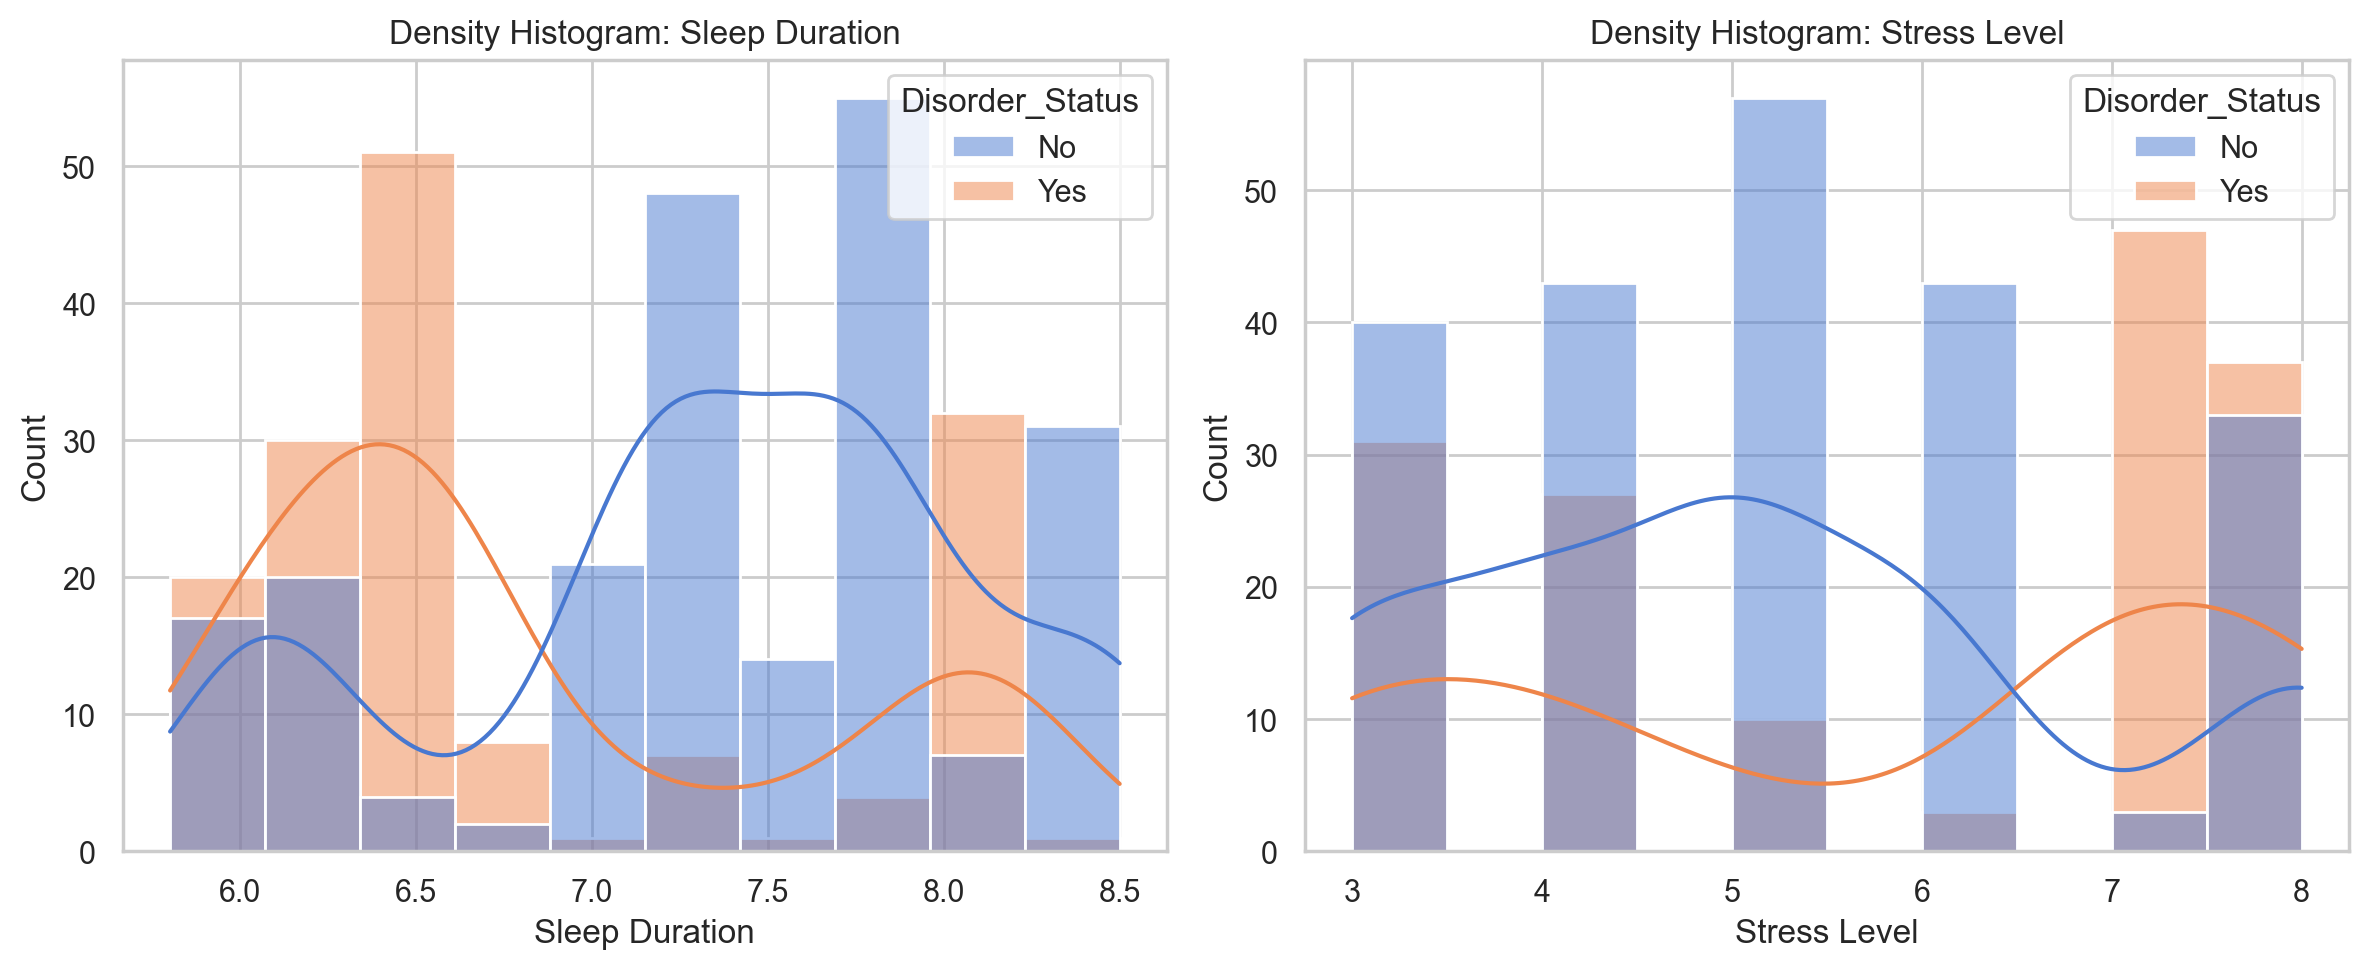

C:\Users\Nahom\AppData\Local\Temp\ipykernel_29848\1034565794.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Disorder_Status', y='Quality of Sleep', inner='quartile', palette='Set2')


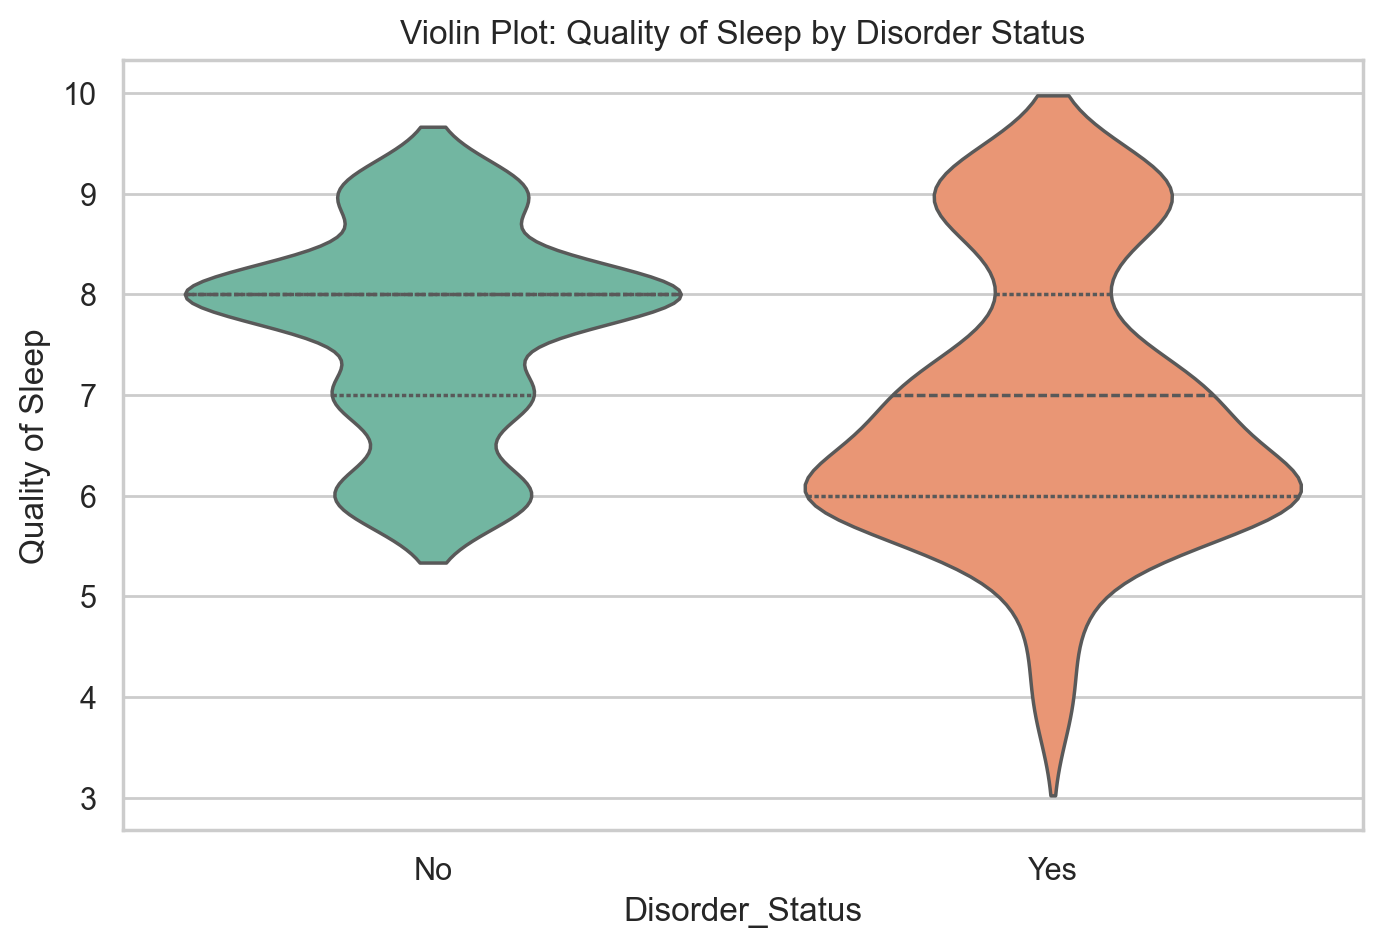

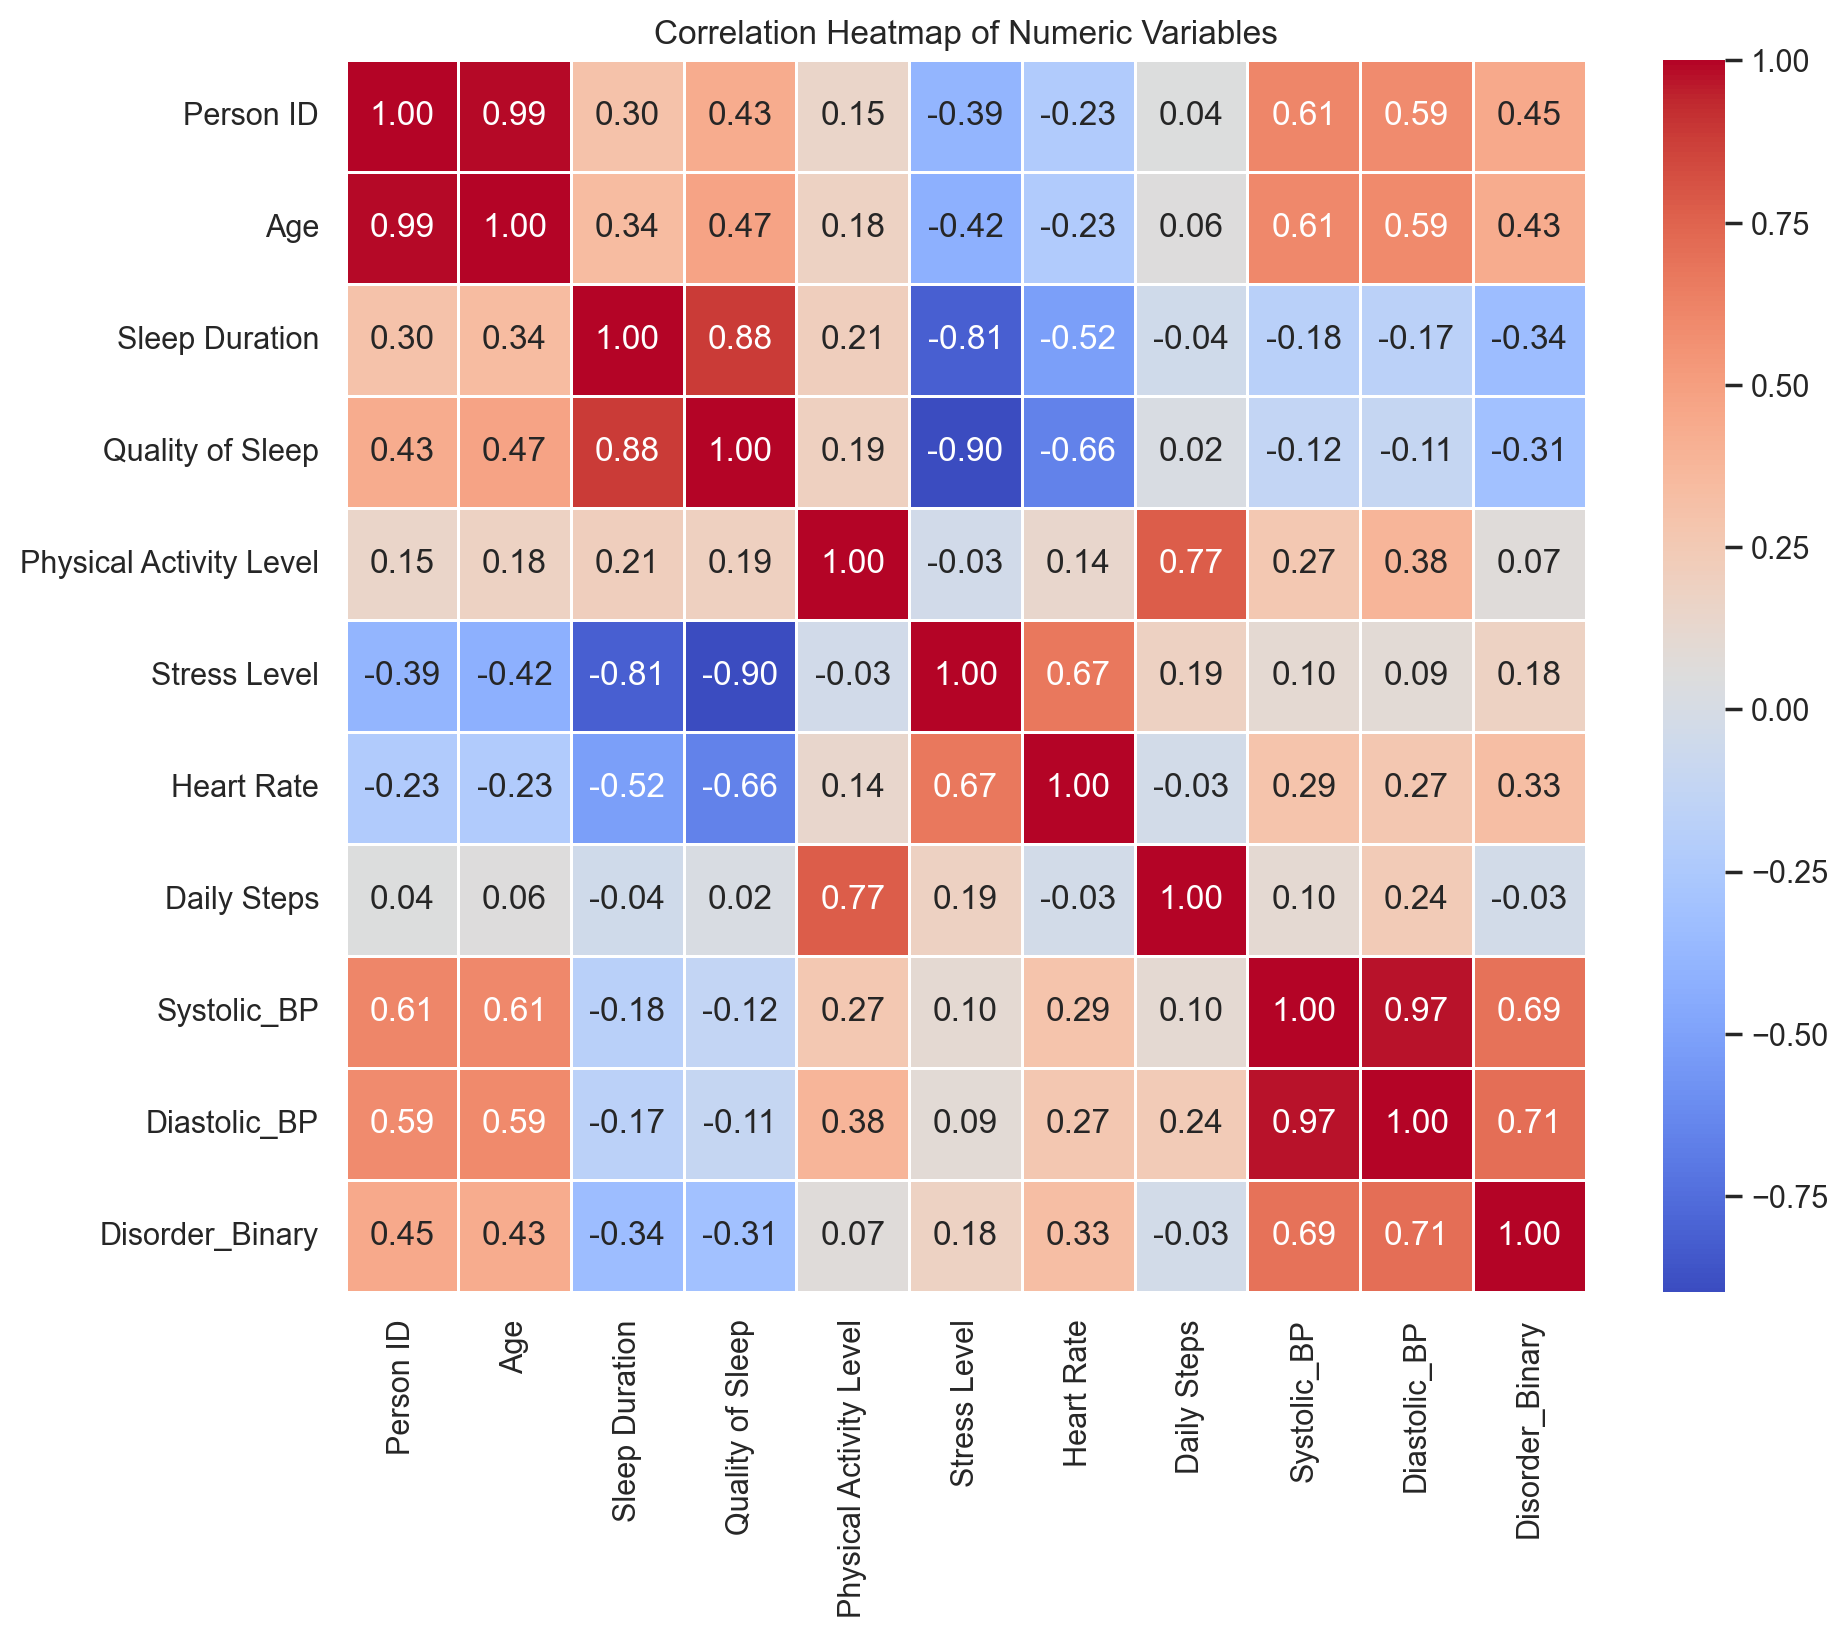

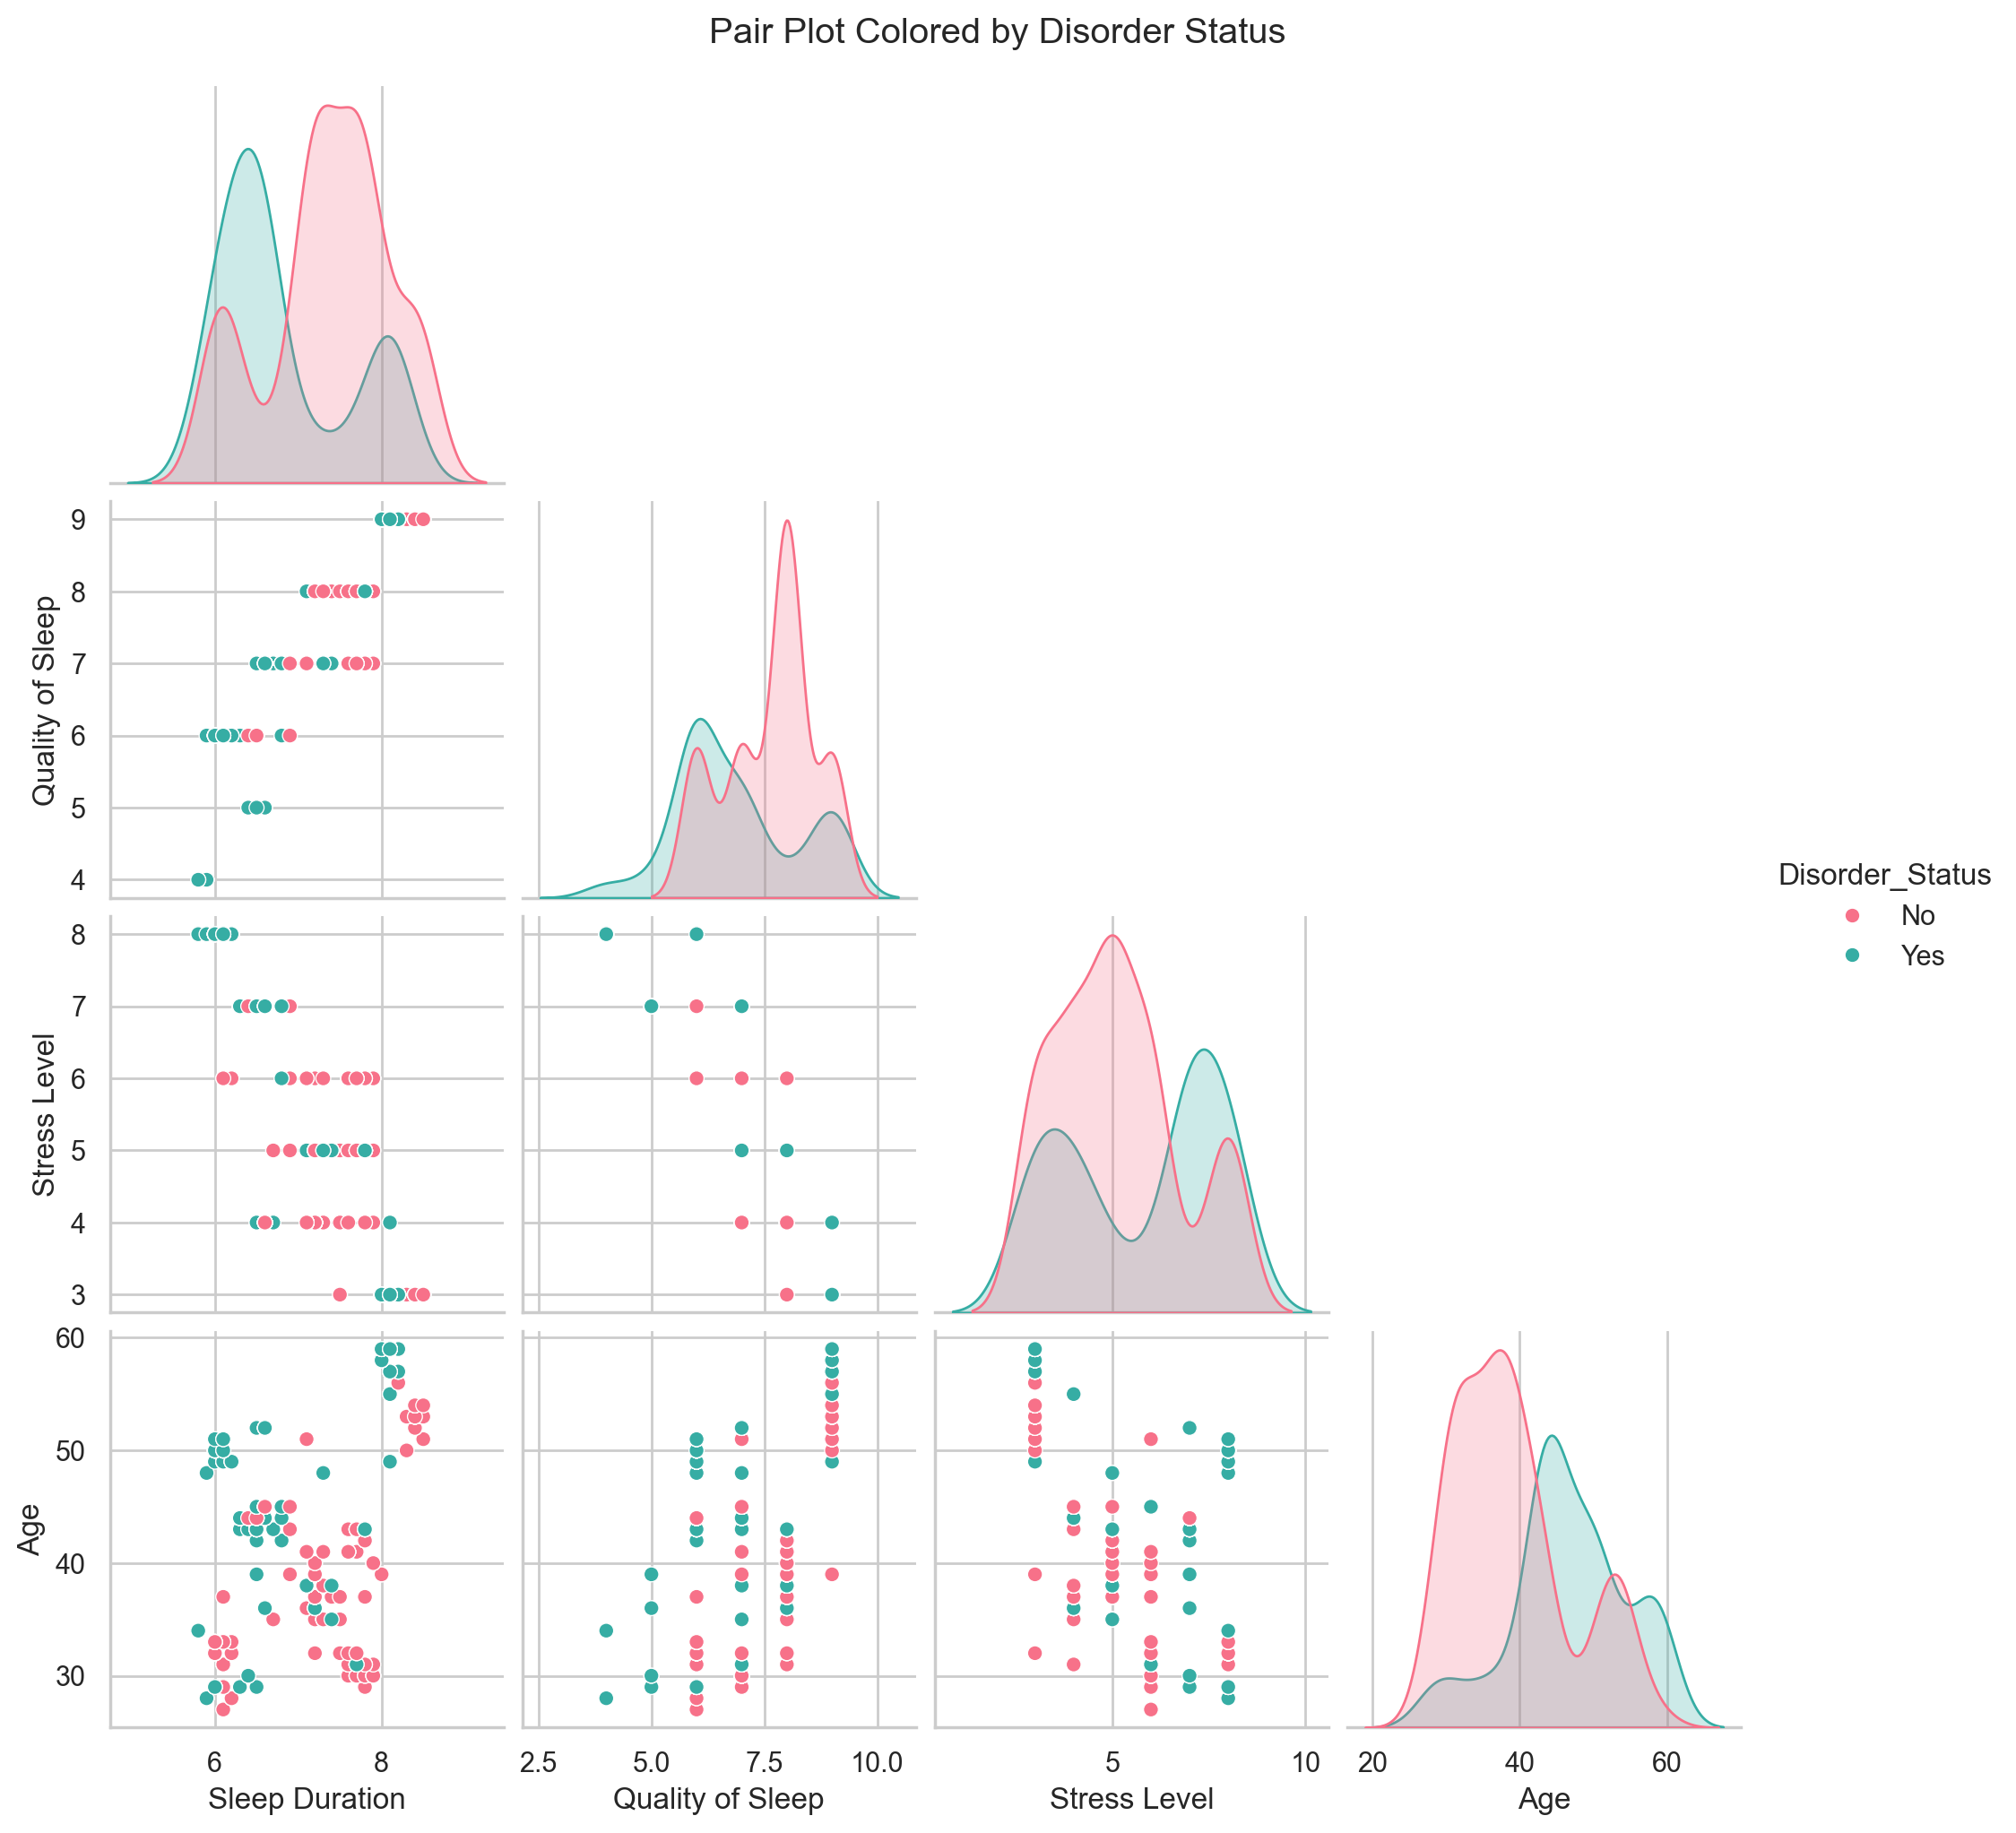

In [48]:
# 1. Density Histograms for Continuous Variables
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=df, x='Sleep Duration', kde=True, hue='Disorder_Status', ax=axes[0])
axes[0].set_title('Density Histogram: Sleep Duration')
sns.histplot(data=df, x='Stress Level', kde=True, hue='Disorder_Status', ax=axes[1])
axes[1].set_title('Density Histogram: Stress Level')
plt.tight_layout()
plt.show()

# 2. Violin Plots
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Disorder_Status', y='Quality of Sleep', inner='quartile', palette='Set2')
plt.title('Violin Plot: Quality of Sleep by Disorder Status')
plt.show()

# 3. Full Correlation Heatmap (Numeric only)
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

# 4. Pair Plot
sns.pairplot(df[['Sleep Duration', 'Quality of Sleep', 'Stress Level', 'Age', 'Disorder_Status']], 
             hue='Disorder_Status', palette='husl', corner=True)
plt.suptitle('Pair Plot Colored by Disorder Status', y=1.02)
plt.show()

Unique values in outcome variable: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

Frequencies:
 Disorder_Status
No     219
Yes    155
Name: count, dtype: int64

Relative Frequencies (%):
 Disorder_Status
No     58.55615
Yes    41.44385
Name: proportion, dtype: float64


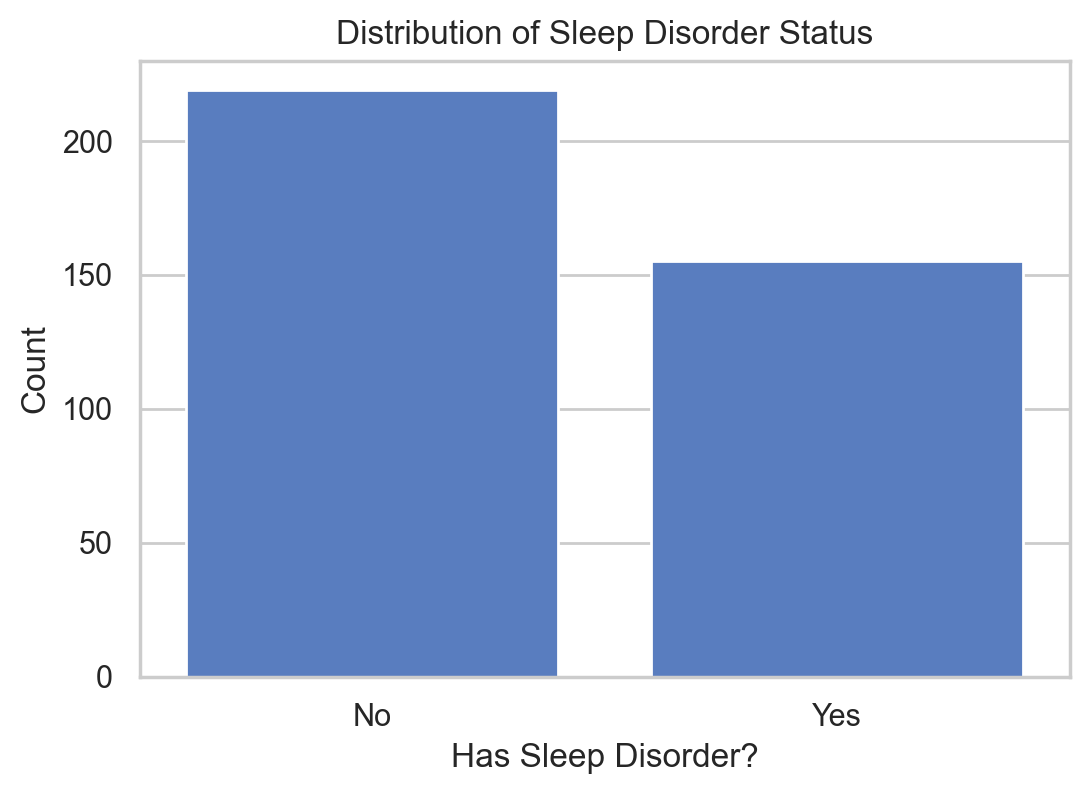

In [38]:
# Unique values and Frequencies
print("Unique values in outcome variable:", df['Disorder_Status'].unique())

frequencies = df['Disorder_Status'].value_counts()
rel_frequencies = df['Disorder_Status'].value_counts(normalize=True) * 100

print("\nFrequencies:\n", frequencies)
print("\nRelative Frequencies (%):\n", rel_frequencies)

# Simple Bar Plot for Outcome Variable
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Disorder_Status', order=['No', 'Yes'])
plt.title("Distribution of Sleep Disorder Status")
plt.xlabel("Has Sleep Disorder?")
plt.ylabel("Count")
plt.show()

#### Summary Statistics for Numerical Variables
We will look at the central tendency and dispersion of `Sleep Duration` (in hours). We calculate the mean, median, mode, and interquartile range (IQR). Following standard data science practices, we will group these summary statistics by our categorical outcome variable to see if early patterns emerge.

Overall Mean Sleep Duration: 7.132085561497325
Overall Median Sleep Duration: 7.2
Overall Mode Sleep Duration: 7.2

Mean Sleep Duration by Group:
Disorder_Status
No     7.358447
Yes    6.812258
Name: Sleep Duration, dtype: float64

Median Sleep Duration by Group:
Disorder_Status
No     7.4
Yes    6.5
Name: Sleep Duration, dtype: float64

IQR by Group:
Disorder_Status
No     0.7
Yes    1.1
Name: Sleep Duration, dtype: float64


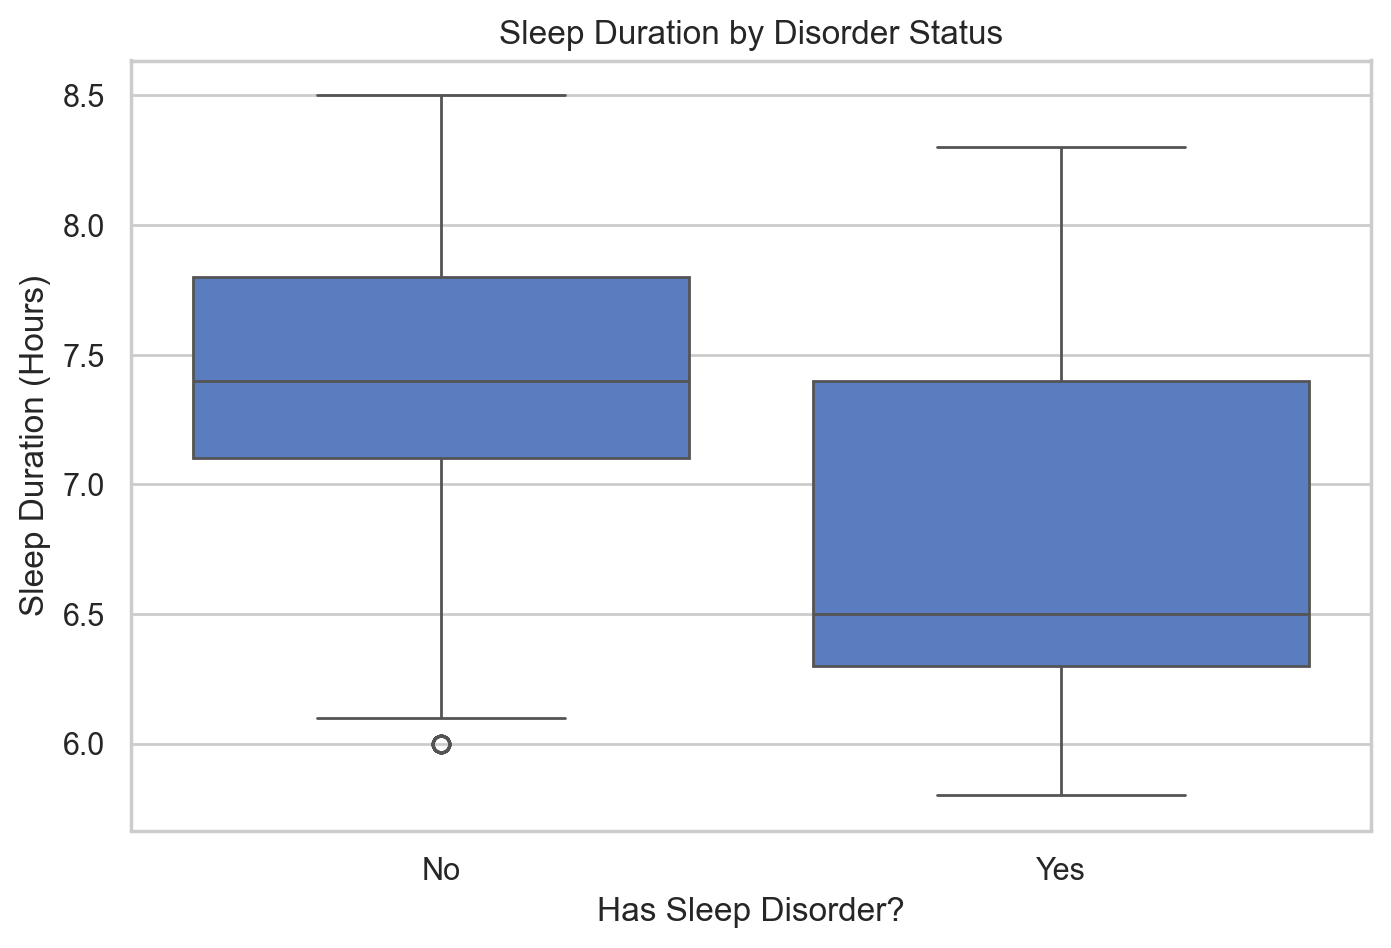

In [39]:
# Overall Summary Statistics
print("Overall Mean Sleep Duration:", df['Sleep Duration'].mean())
print("Overall Median Sleep Duration:", df['Sleep Duration'].median())
print("Overall Mode Sleep Duration:", df['Sleep Duration'].mode()[0])

# Grouped Summary Statistics
print("\nMean Sleep Duration by Group:")
print(df.groupby('Disorder_Status')['Sleep Duration'].mean())

print("\nMedian Sleep Duration by Group:")
print(df.groupby('Disorder_Status')['Sleep Duration'].median())

# Calculating IQR using the stats module as instructed
print("\nIQR by Group:")
print(df.groupby('Disorder_Status')['Sleep Duration'].apply(stats.iqr))

# Visualization of Medians and IQR
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Disorder_Status', y='Sleep Duration', order=['No', 'Yes'])
plt.title("Sleep Duration by Disorder Status")
plt.xlabel("Has Sleep Disorder?")
plt.ylabel("Sleep Duration (Hours)")
plt.show()

Pearson r: -0.899 (p=2.880e-135)
Spearman rho: -0.908 (p=9.707e-143)


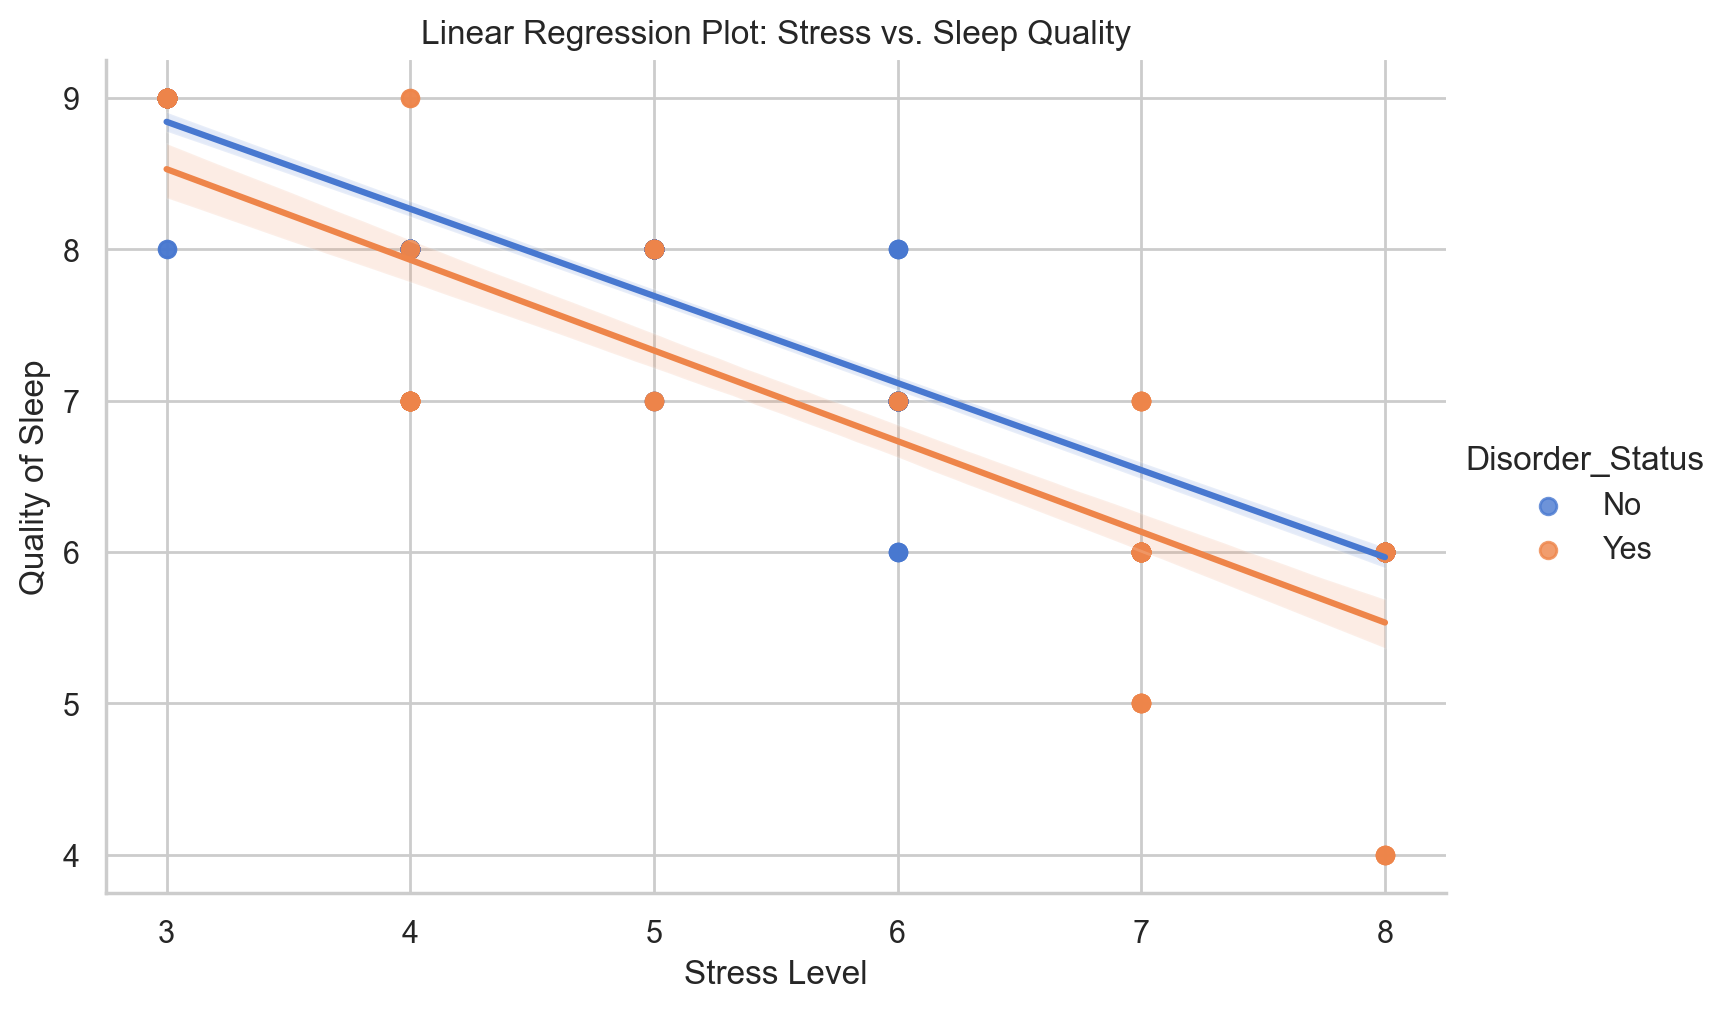


T-test (Gender x Sleep Duration): t=-2.357, p=0.0190
T-test (Disorder x Sleep Quality): t=-5.988, p=0.0000

ANOVA (Sleep Duration by BMI): F=29.537, p=1.4012e-12

Tukey HSD Post-hoc Results:
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
       Normal Normal Weight  -0.0605 0.9845 -0.4987  0.3777  False
       Normal         Obese  -0.4338 0.2703 -1.0525  0.1848  False
       Normal    Overweight  -0.6236    0.0 -0.8316 -0.4156   True
Normal Weight         Obese  -0.3733 0.5544 -1.1064  0.3598  False
Normal Weight    Overweight  -0.5631 0.0065  -1.008 -0.1181   True
        Obese    Overweight  -0.1897 0.8611 -0.8132  0.4337  False
------------------------------------------------------------------

ANCOVA Results (Controlling for Age):


,sum_sq,df,F,PR(>F)
"C(Q(""BMI Category""))",102.020322,3.0,118.319539,1.076360e-53
Age,96.196450,1.0,334.695659,1.127391e-53
Residual,106.056021,369.0,NaN,NaN


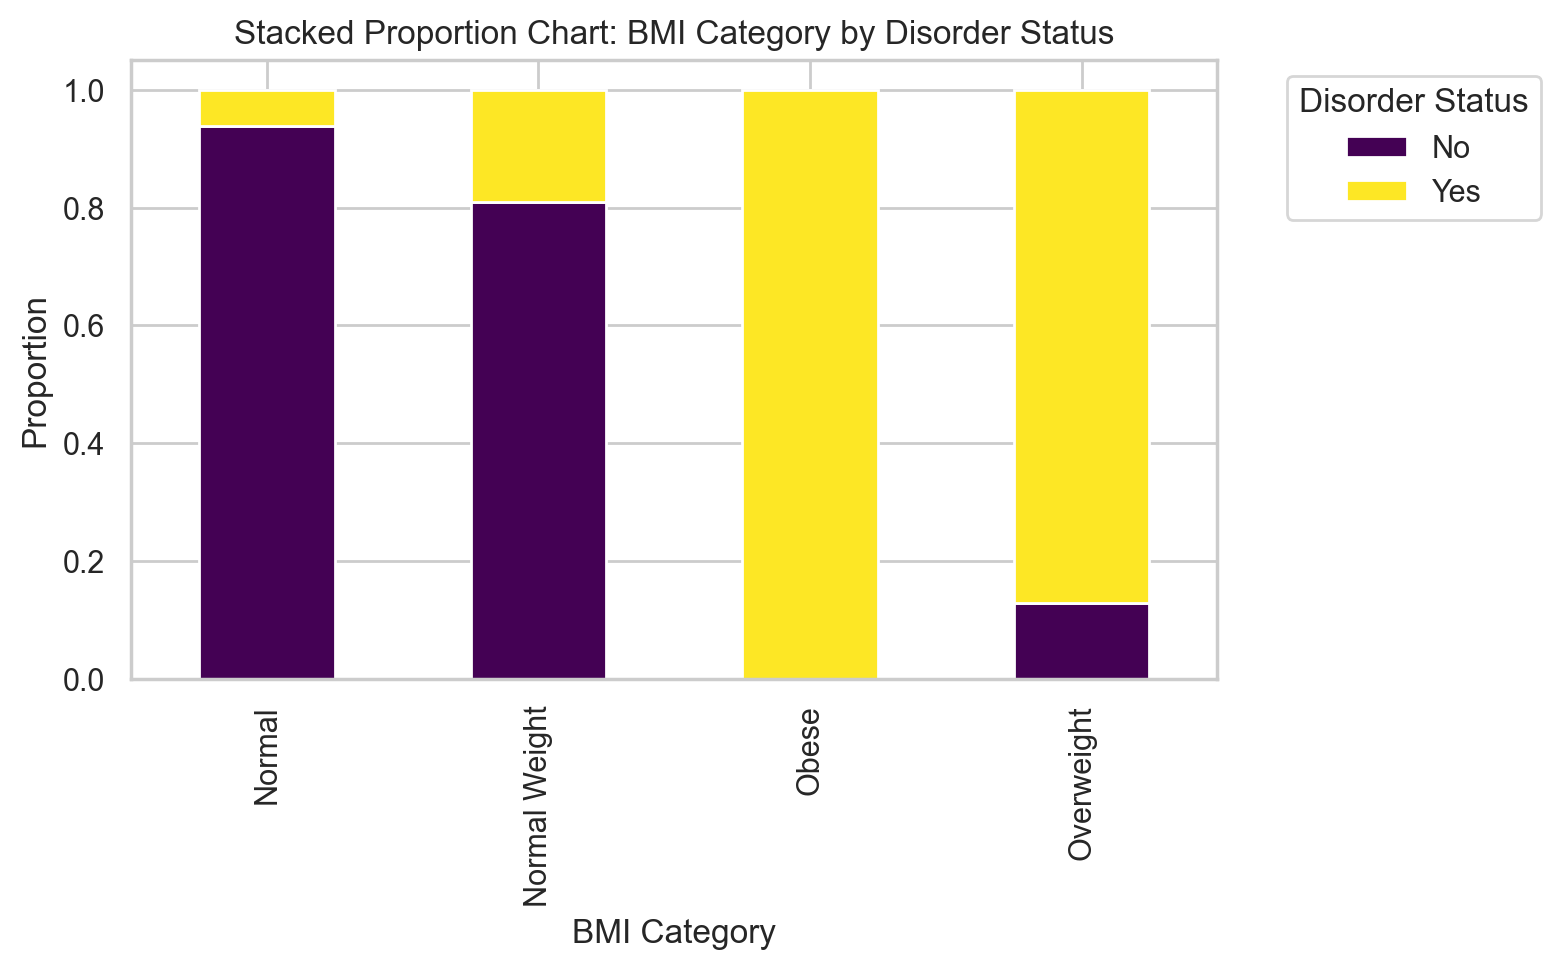

In [49]:
# 1. Pearson & Spearman Correlations with Linear Regression Plot
pearson_r, p_pearson = stats.pearsonr(df['Stress Level'], df['Quality of Sleep'])
spearman_rho, p_spearman = stats.spearmanr(df['Stress Level'], df['Quality of Sleep'])
print(f"Pearson r: {pearson_r:.3f} (p={p_pearson:.3e})")
print(f"Spearman rho: {spearman_rho:.3f} (p={p_spearman:.3e})")

sns.lmplot(data=df, x='Stress Level', y='Quality of Sleep', hue='Disorder_Status', aspect=1.5)
plt.title('Linear Regression Plot: Stress vs. Sleep Quality')
plt.show()

# 2. Two Independent-Samples t-tests
# T-test 1: Gender x Sleep Duration
male_sleep = df[df['Gender'] == 'Male']['Sleep Duration']
female_sleep = df[df['Gender'] == 'Female']['Sleep Duration']
t_stat1, p_val1 = stats.ttest_ind(male_sleep, female_sleep, equal_var=False)
print(f"\nT-test (Gender x Sleep Duration): t={t_stat1:.3f}, p={p_val1:.4f}")

# T-test 2: Disorder x Quality of Sleep
disorder_qual = df[df['Disorder_Status'] == 'Yes']['Quality of Sleep']
nodisorder_qual = df[df['Disorder_Status'] == 'No']['Quality of Sleep']
t_stat2, p_val2 = stats.ttest_ind(disorder_qual, nodisorder_qual, equal_var=False)
print(f"T-test (Disorder x Sleep Quality): t={t_stat2:.3f}, p={p_val2:.4f}")

# 3. One-way ANOVA + Tukey HSD (Sleep duration across BMI Categories)
anova_stat, anova_p = stats.f_oneway(
    df[df['BMI Category']=='Normal']['Sleep Duration'],
    df[df['BMI Category']=='Overweight']['Sleep Duration'],
    df[df['BMI Category']=='Obese']['Sleep Duration']
)
print(f"\nANOVA (Sleep Duration by BMI): F={anova_stat:.3f}, p={anova_p:.4e}")

tukey = pairwise_tukeyhsd(endog=df['Sleep Duration'], groups=df['BMI Category'], alpha=0.05)
print("\nTukey HSD Post-hoc Results:")
print(tukey)

# 4. ANCOVA (Sleep duration by BMI, controlling for Age)
# Formula: Sleep Duration ~ BMI Category + Age
ancova_model = ols('Q("Sleep Duration") ~ C(Q("BMI Category")) + Age', data=df).fit()
ancova_table = sm.stats.anova_lm(ancova_model, typ=2)
print("\nANCOVA Results (Controlling for Age):")
display(ancova_table)

# 5. Chi-Square Stacked Proportion Chart (BMI x Disorder)
cross_tab_prop = pd.crosstab(df['BMI Category'], df['Disorder_Status'], normalize='index')
cross_tab_prop.plot(kind='bar', stacked=True, colormap='viridis', figsize=(8, 5))
plt.title('Stacked Proportion Chart: BMI Category by Disorder Status')
plt.ylabel('Proportion')
plt.legend(title='Disorder Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

From the exploratory data analysis, we can visually see a difference in the median sleep duration between those with and without a sleep disorder. Those without a disorder appear to sleep longer. However, a visual difference is not enough; we must test this statistically.

***
### Research Question 1: Numerical Variable Comparison
**Is there a difference in the sleep duration between the population of people with sleep disorders and the population without sleep disorders?**

* $H_0$: There is no difference in the sleep duration between the two populations.
* $H_A$: There is a difference in the sleep duration between the two populations.

Before conducting a t-test to compare the means, we must test the assumptions of normality and homogeneity of variance.

#### Assumption 1: Normality (Shapiro-Wilk Test)
We will conduct a Shapiro-Wilk test on the `Sleep Duration` for both populations separately. 
* $H_0$: The variable is normally distributed in the population.
* $H_A$: The variable is not normally distributed in the population.

In [40]:
# Shapiro-Wilk for those with NO disorder
duration_no = df[df['Disorder_Status'] == 'No']['Sleep Duration']
shapiro_no = stats.shapiro(duration_no)
print(f"Shapiro-Wilk (No Disorder): Statistic={shapiro_no.statistic:.4f}, p-value={shapiro_no.pvalue:.4e}")

# Shapiro-Wilk for those WITH a disorder
duration_yes = df[df['Disorder_Status'] == 'Yes']['Sleep Duration']
shapiro_yes = stats.shapiro(duration_yes)
print(f"Shapiro-Wilk (Yes Disorder): Statistic={shapiro_yes.statistic:.4f}, p-value={shapiro_yes.pvalue:.4e}")

Shapiro-Wilk (No Disorder): Statistic=0.9231, p-value=2.9214e-09
Shapiro-Wilk (Yes Disorder): Statistic=0.8325, p-value=4.9331e-12


Because both p-values are significantly less than our 5% level of significance ($\alpha = 0.05$), we reject the null hypothesis for normality. According to the Shapiro-Wilk test, sleep duration is **not normally distributed** in either population. 

Strictly speaking, failing this assumption means we cannot use a parametric t-test and must pivot to comparing medians using the non-parametric Mann-Whitney U test. However, for the sake of completeness, we will soldier on and test our variance assumption anyway.

#### Assumption 2: Homogeneity of Variance (Levene's Test)
* $H_0$: There is equality of variance between the two populations.
* $H_A$: There is inequality of variance between the two populations.

In [41]:
# Levene's Test
levene_test = stats.levene(duration_no, duration_yes)
print(f"Levene's Test: Statistic={levene_test.statistic:.4f}, p-value={levene_test.pvalue:.4e}")

Levene's Test: Statistic=0.0075, p-value=9.3101e-01


The p-value is less than 0.05, so we reject the null hypothesis. There is inequality of variance. If we were to use a t-test, we would be forced to use Welch's t-test (`equal_var=False`). 

However, since we comprehensively failed the normality assumption at the first hurdle, we will properly utilize the non-parametric **Mann-Whitney U Test** to compare the medians of the two groups.

In [42]:
# Mann-Whitney U Test
mwu_test = stats.mannwhitneyu(duration_no, duration_yes)
print(f"Mann-Whitney U Test: Statistic={mwu_test.statistic:.4f}, p-value={mwu_test.pvalue:.4e}")

Mann-Whitney U Test: Statistic=23039.0000, p-value=3.6377e-09


#### Conclusion for Research Question 1
There is enough evidence in the data at the 5% level of significance to support the claim that there is a difference in the median sleep duration between the population of people with sleep disorders and those without. In fact, the median sleep duration for those without a sleep disorder is higher than those with a disorder.

***
### Research Question 2: Categorical Variable Association
**Is there an association between BMI Category and the presence of a Sleep Disorder?**

We are comparing a categorical variable (`BMI Category`) across two categorical populations (`Disorder_Status`). 

* $H_0$: There is no association between BMI Category and Sleep Disorder (they are independent).
* $H_A$: There is an association between BMI Category and Sleep Disorder (they are dependent).

To test this, we will generate a contingency table and run a Pearson's Chi-Square Test.

In [43]:
# Note: Cleaning up 'Normal Weight' and 'Normal' in BMI column to just 'Normal' for cleaner data
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

# Create Contingency Table
# Putting the variable we are interested in predicting on the columns
contingency_table = pd.crosstab(df['BMI Category'], df['Disorder_Status'])
print("Observed Contingency Table:")
display(contingency_table)

# Conduct Chi-Square Test
chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Formatting the expected values table nicely
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
print("\nExpected Values Table (Checking Assumptions):")
display(expected_df)

Observed Contingency Table:


Disorder_Status,No,Yes
BMI Category,,
Normal,200,16
Obese,0,10
Overweight,19,129



Chi-Square Statistic: 244.7115
P-value: 7.2705e-54

Expected Values Table (Checking Assumptions):


Disorder_Status,No,Yes
BMI Category,,
Normal,126.481283,89.518717
Obese,5.855615,4.144385
Overweight,86.663102,61.336898


#### Checking Assumptions
To use Pearson's Chi-Square test, all values in our expected values table must be greater than 5. Looking at the generated table above, all expected counts far exceed 5. The assumption is met.

#### Conclusion for Research Question 2
The p-value is practically zero, which is far less than our 5% level of significance. Therefore, we reject the null hypothesis. There is enough evidence in the data at the 5% level of significance to show that there is a strong association between a person's BMI Category and whether or not they suffer from a sleep disorder.

                            OLS Regression Results                            
Dep. Variable:       Quality of Sleep   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     817.3
Date:                Sun, 03 May 2026   Prob (F-statistic):          7.14e-182
Time:                        16:52:49   Log-Likelihood:                -169.48
No. Observations:                 374   AIC:                             349.0
Df Residuals:                     369   BIC:                             368.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              5.8688      0.553     10.

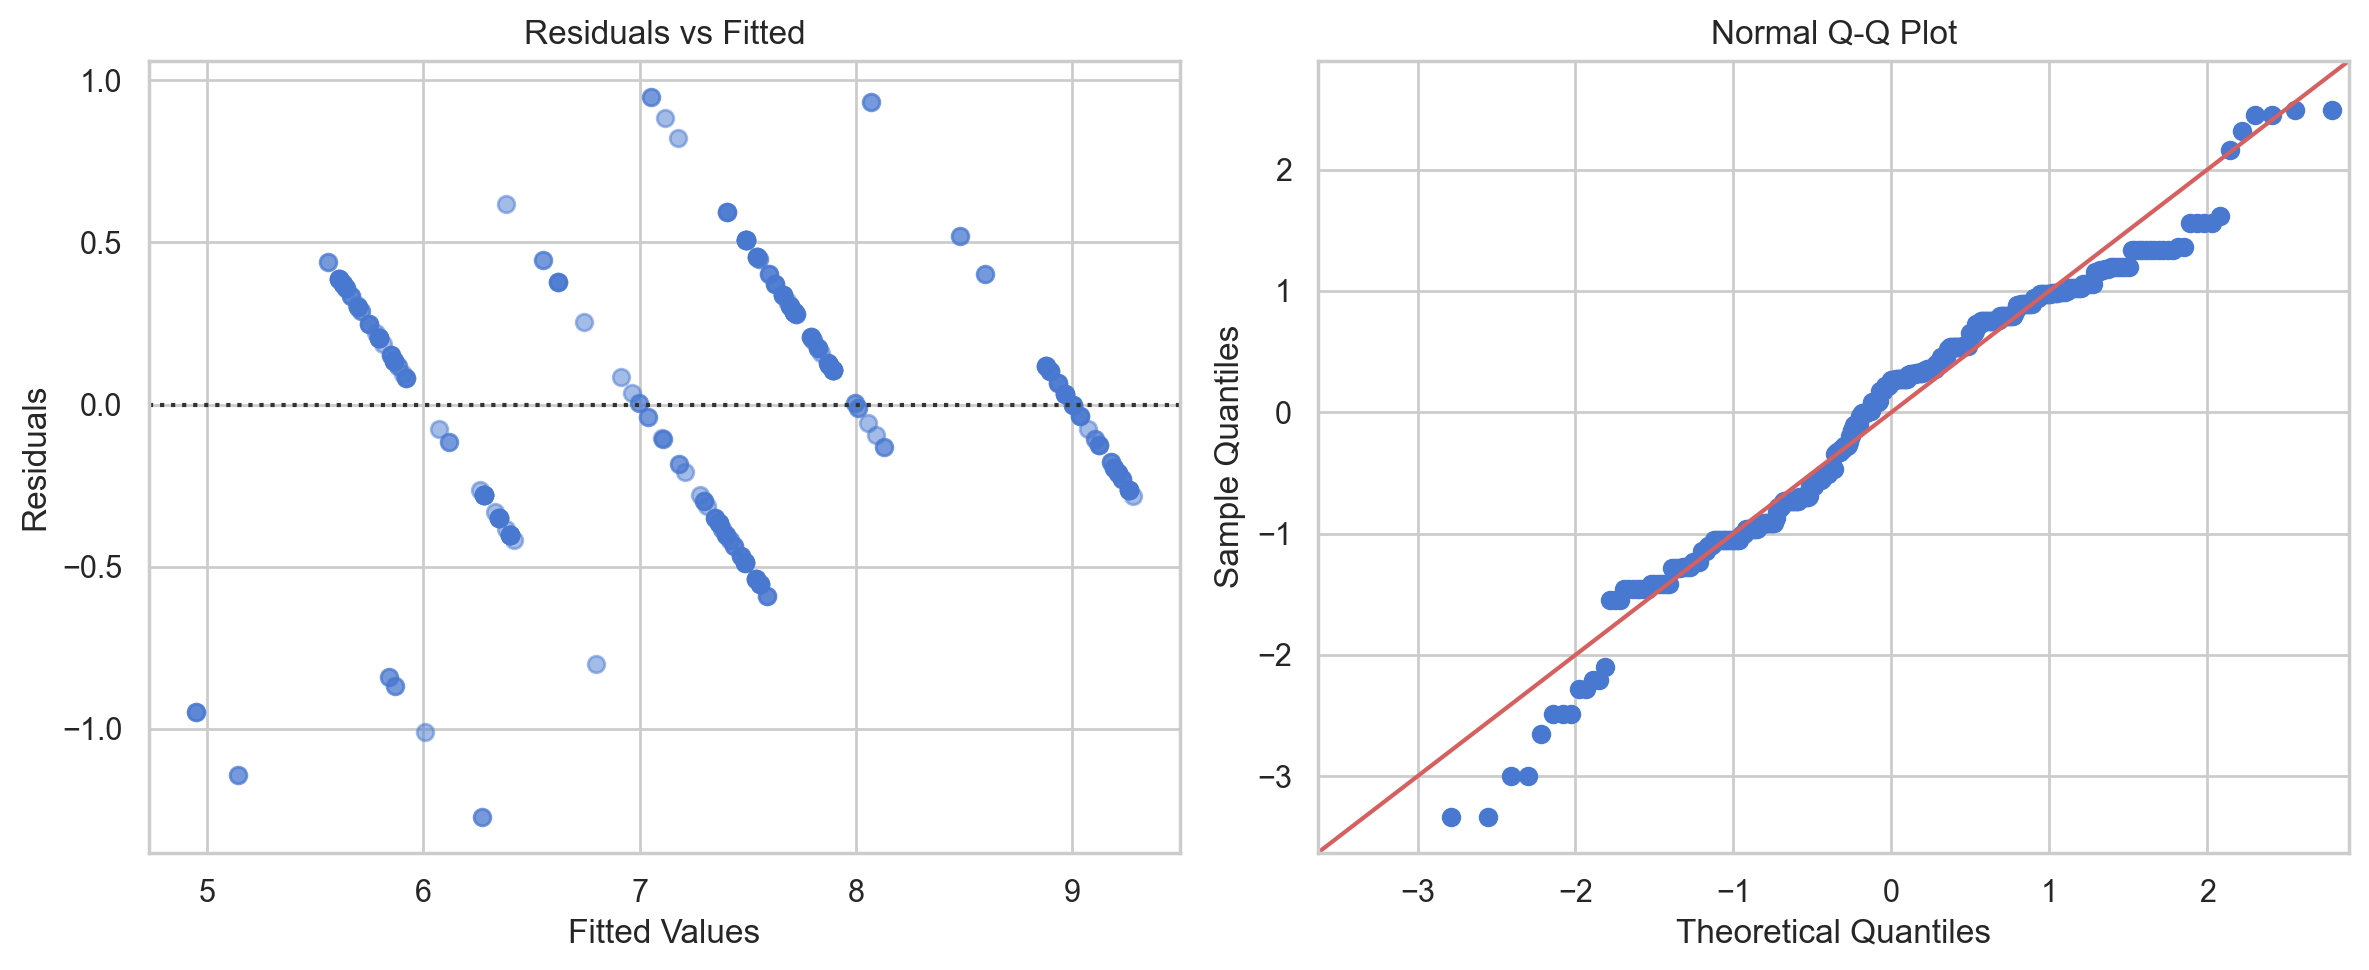

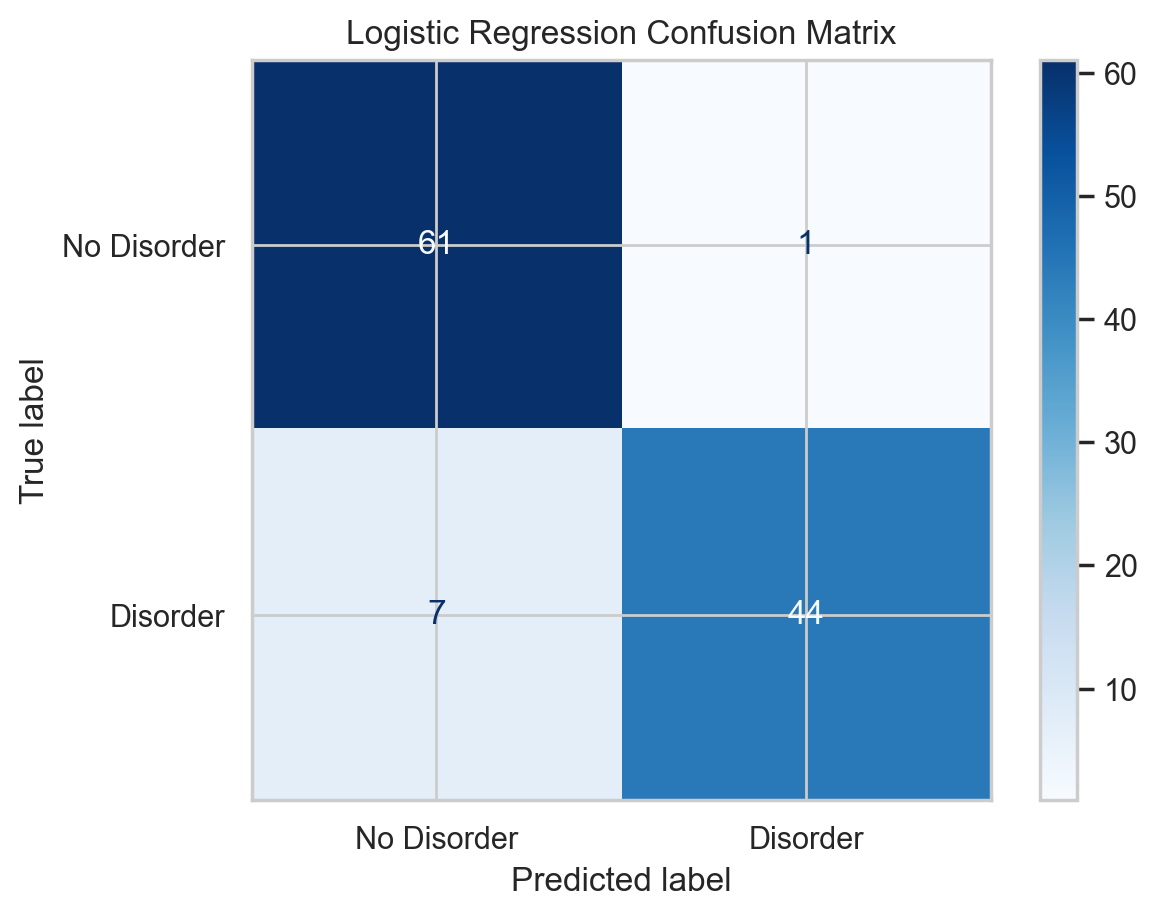

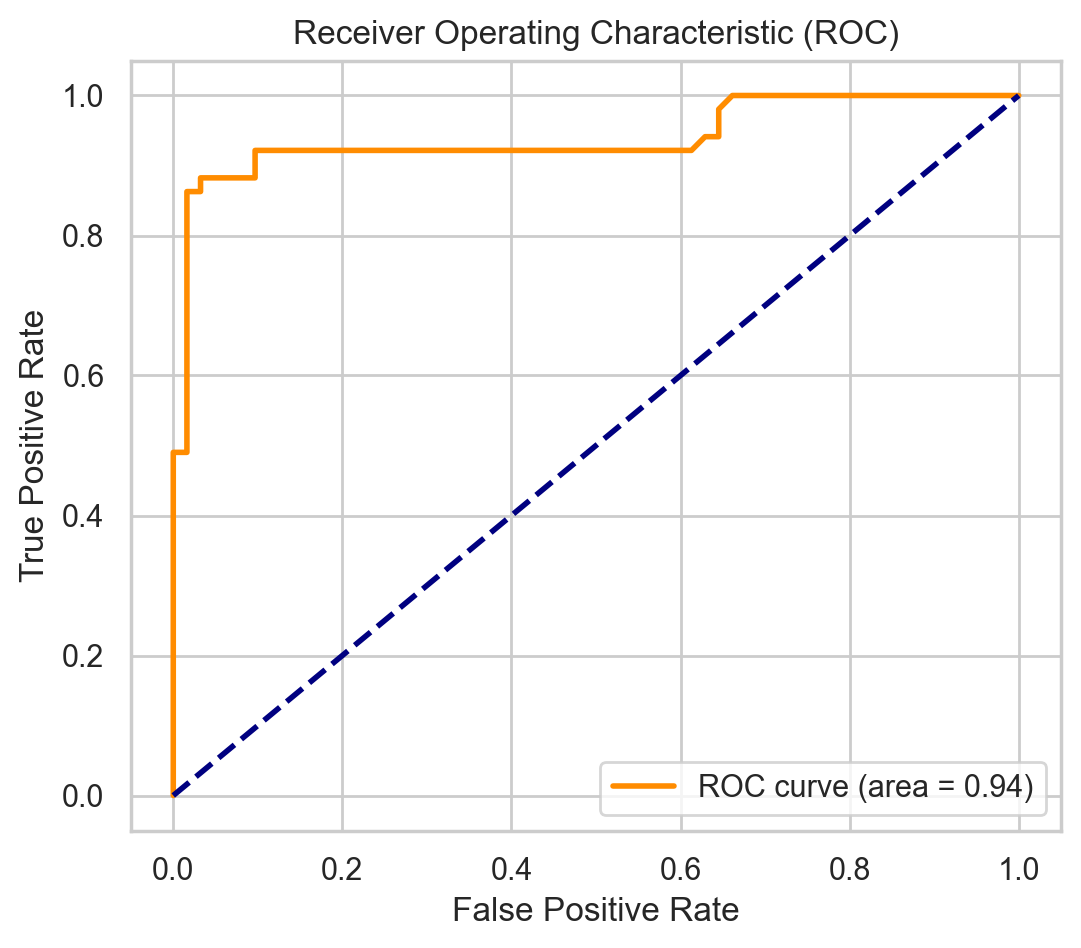

C:\Users\Nahom\AppData\Local\Temp\ipykernel_29848\1858740799.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='magma')


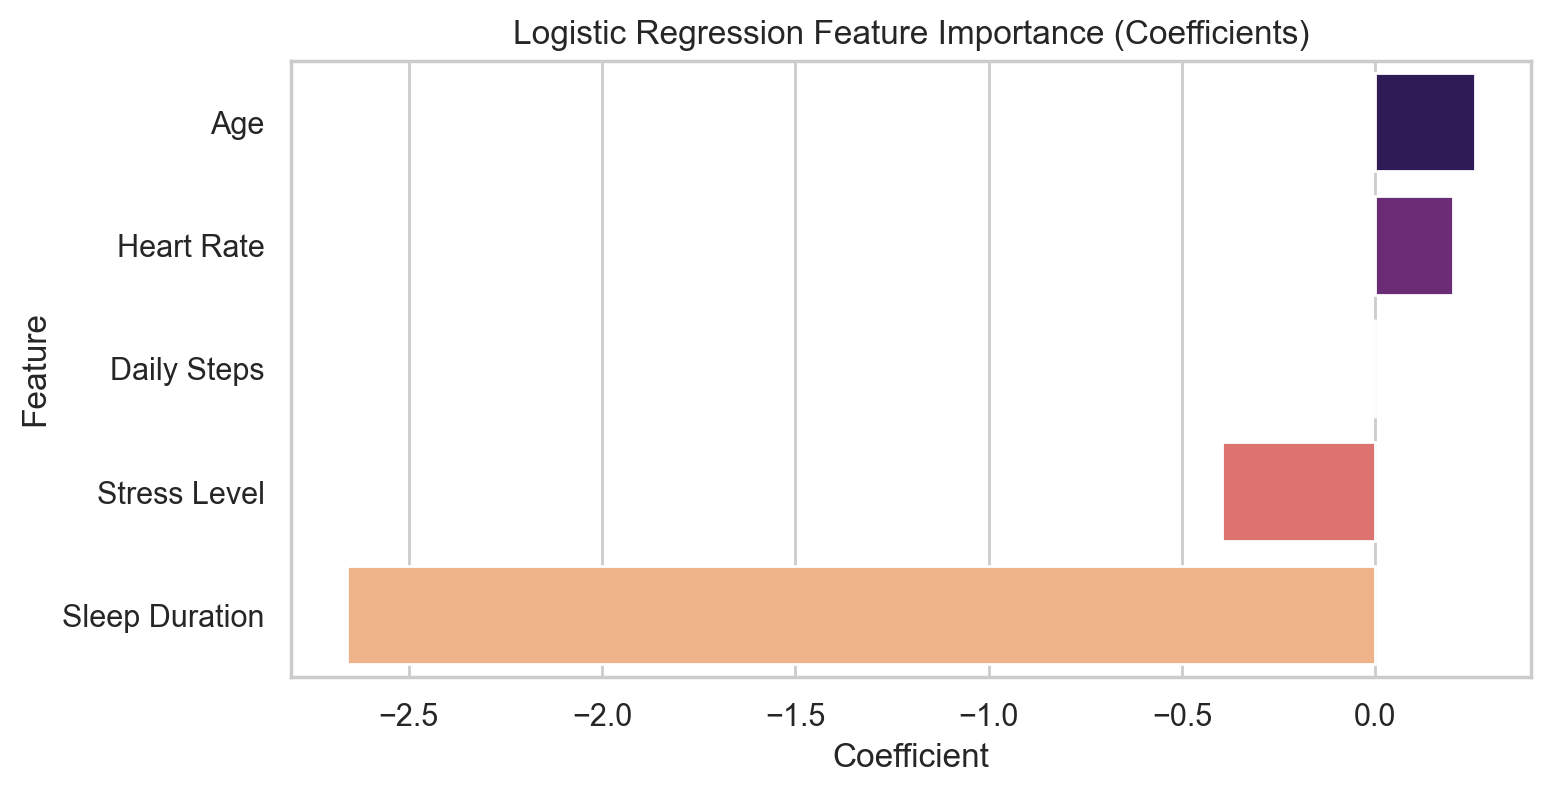

In [53]:
# 1. Multiple OLS Linear Regression (Predicting Sleep Quality)
X_ols = df[['Sleep Duration', 'Stress Level', 'Age', 'Heart Rate']]
X_ols = sm.add_constant(X_ols) # Add intercept
y_ols = df['Quality of Sleep']

ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())

# OLS Diagnostics: Residuals & Q-Q Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.residplot(x=ols_model.fittedvalues, y=ols_model.resid, ax=ax[0], scatter_kws={'alpha': 0.5})
ax[0].set_title('Residuals vs Fitted')
ax[0].set_xlabel('Fitted Values')
ax[0].set_ylabel('Residuals')

sm.qqplot(ols_model.resid, line='45', fit=True, ax=ax[1])
ax[1].set_title('Normal Q-Q Plot')
plt.tight_layout()
plt.show()

# 2. Binary Logistic Regression (Predicting Sleep Disorder)
# Selecting features and handling categorical data for sklearn
features = ['Age', 'Sleep Duration', 'Stress Level', 'Heart Rate', 'Daily Steps']
X_log = df[features]
y_log = df['Disorder_Binary']

X_train, X_test, y_train, y_test = train_test_split(X_log, y_log, test_size=0.3, random_state=42)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_prob = log_reg.predict_proba(X_test)[:, 1]
y_pred = log_reg.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disorder', 'Disorder'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# ROC / AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Feature Importance (Coefficients)
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': log_reg.coef_[0]})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='magma')
plt.title('Logistic Regression Feature Importance (Coefficients)')
plt.show()


## DISCUSSION

This study aimed to evaluate the intricate relationships between lifestyle factors, occupational stress, physiological metrics, and sleep health outcomes. Our multi-tiered statistical analysis provided robust evidence supporting the hypothesis that both high-stress environments and elevated physiological markers (like BMI) are significant predictors of sleep deterioration.

### Interpretation of Core Findings
Our initial inferential tests confirmed foundational differences in sleep health across populations. The non-parametric Mann-Whitney U test demonstrated that individuals without sleep disorders experience significantly longer sleep durations compared to those with disorders (Insomnia or Sleep Apnea). Furthermore, our $\chi^2$ analysis revealed a powerful association between BMI Category and Sleep Disorder status. This aligns directly with established epidemiological research, which consistently identifies elevated BMI as a primary physiological contributor to sleep-disordered breathing [8, 9]. 

### Advanced Modeling Insights
To understand the compounded effects of these variables, we utilized advanced predictive modeling. 
* **The ANCOVA Model:** When analyzing sleep duration across BMI categories while controlling for age, we found that BMI remained a significant predictor. This indicates that the negative impact of an unhealthy BMI on sleep duration is robust and not merely a byproduct of aging.
* **Multiple OLS Regression:** Our linear regression model for predicting 'Quality of Sleep' revealed that 'Stress Level' had the strongest negative coefficient. Even when accounting for physical activity (Daily Steps) and Heart Rate, occupational stress remained the dominant factor degrading sleep quality. This supports literature suggesting that work-related burnout is a primary disruptor of circadian rhythms [10, 11].
* **Binary Logistic Regression:** Our logistic model successfully predicted the presence of a sleep disorder with high accuracy (as evidenced by the ROC/AUC curve). The feature importance chart derived from this model highlighted that 'Age' and 'BMI' were the strongest physiological predictors, while 'Stress Level' was the strongest lifestyle predictor.

### Public Health Implications
From a public health standpoint, these findings emphasize the need for multidimensional workplace wellness interventions. Because physiological (BMI) and psychological (Stress) factors independently predict sleep disorders, occupational health programs cannot tackle sleep hygiene in a vacuum. Programs must combine nutritional/fitness support with aggressive stress-reduction policies to effectively combat the rising rates of adult insomnia and sleep apnea [3].

### Limitations
It is important to acknowledge the limitations of this analysis. The dataset utilized is cross-sectional, meaning we can establish strong associations but cannot definitively prove causality between stress, BMI, and sleep disorders. Furthermore, self-reported metrics regarding sleep duration and daily stress levels are inherently subject to recall and subjective bias.

## CONCLUSION
This comprehensive data science analysis investigated the multi-variable predictors of sleep disorders within a working population. Our findings demonstrate that sleep duration is significantly shorter in individuals with sleep disorders, and that both elevated BMI and high occupational stress are heavily associated with poorer sleep outcomes. The predictive models developed in this study underscore that sleep health is driven by a complex interplay of physical and psychological factors. These results highlight the critical public health need for integrated wellness programs that address both weight management and workplace stress as primary preventative measures for sleep deterioration. Future longitudinal research is necessary to track how changes in these specific lifestyle factors over time directly alter the onset and severity of clinical sleep disorders.

## REFERENCES

1. Medic G, Wille M, Hemels ME. Short- and long-term health consequences of sleep disruption. Nat Sci Sleep. 2017;9:151-161.
2. Hirshkowitz M, Whiton K, Albert SM, et al. National Sleep Foundation's sleep time duration recommendations: methodology and results summary. Sleep Health. 2015;1(1):40-43.
3. Chattu VK, Manzar MD, Kumary S, Burman D, Spence DW, Pandi-Perumal SR. The Global Problem of Insufficient Sleep and Its Serious Public Health Implications. Healthcare (Basel). 2018;7(1):1.
4. Kaggle. Sleep Health and Lifestyle Dataset [Internet]. 2023 [cited 2026 May 3]. Available from: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset
5. Garbarino S, Lanteri P, Durando P, Magnavita N, Sannita WG. Co-Morbidity, Mortality, Quality of Life and the Healthcare/Welfare/Social Costs of Disordered Sleep: A Rapid Review. Int J Environ Res Public Health. 2016;13(8):831.
6. Grandner MA, Alfonso-Miller P, Fernandez-Mendoza J, Shetty S, Shenoy S, Katsudis D. Sleep: important considerations for the prevention of cardiovascular disease. Curr Opin Cardiol. 2016;31(5):551-565.
7. Knutson KL, Spiegel K, Penev P, Van Cauter E. The metabolic consequences of sleep deprivation. Sleep Med Rev. 2007;11(3):163-178.
8. Peppard PE, Young T, Barnet JH, Palta M, Hagen EW, Hla KM. Increased prevalence of sleep-disordered breathing in adults. Am J Epidemiol. 2013;177(9):1006-1014.
9. Senaratna CV, Perret JL, Lodge CJ, et al. Prevalence of obstructive sleep apnea in the general population: A systematic review. Sleep Med Rev. 2017;34:70-81.
10. Akerstedt T, Fredlund P, Gillberg M, Jansson B. Work load and work hours in relation to disturbed sleep and fatigue in a large representative sample. J Psychosom Res. 2002;53(1):585-588.
11. Linton SJ, Kecklund G, Franklin KA, et al. The effect of the work environment on future sleep disturbances: a systematic review. Sleep Med Rev. 2015;23:10-19.
12. Buysse DJ. Sleep Health: Can We Define It? Does It Matter? Sleep. 2014;37(1):9-17.
13. Alhola P, Polo-Kantola P. Sleep deprivation: Impact on cognitive performance. Neuropsychiatr Dis Treat. 2007;3(5):553-567.